<a href="https://colab.research.google.com/github/Anish-Gurav/Backup-of-projects/blob/main/Credit_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Credit Risk Prediction using Machine Learning
## Internship Project - YBI Foundation

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
data = pd.read_csv("https://github.com/YBIFoundation/Dataset/raw/main/Credit%20Default.csv")
data.head()

,Income,Age,Loan,Loan to Income,Default
0,66155.92510,59.017015,8106.532131,0.122537,0
1,34415.15397,48.117153,6564.745018,0.190752,0
2,57317.17006,63.108049,8020.953296,0.139940,0
3,42709.53420,45.751972,6103.642260,0.142911,0
4,66952.68885,18.584336,8770.099235,0.130990,1


## 📊 Step 1: Understanding the Dataset

In this section, we explore the dataset structure, features, and basic statistics.

In [9]:
# Shape of dataset
data.shape

(2000, 5)

In [10]:
# Column names
data.columns

Index(['Income', 'Age', 'Loan', 'Loan to Income', 'Default'], dtype='object')

In [11]:
# Dataset info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Income          2000 non-null   float64
 1   Age             2000 non-null   float64
 2   Loan            2000 non-null   float64
 3   Loan to Income  2000 non-null   float64
 4   Default         2000 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 78.3 KB


In [12]:
# Summary statistics
data.describe()

,Income,Age,Loan,Loan to Income,Default
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,45331.600018,40.927143,4444.369695,0.098403,0.141500
std,14326.327119,13.262450,3045.410024,0.057620,0.348624
min,20014.489470,18.055189,1.377630,0.000049,0.000000
25%,32796.459720,29.062492,1939.708847,0.047903,0.000000
50%,45789.117310,41.382673,3974.719418,0.099437,0.000000
75%,57791.281670,52.596993,6432.410625,0.147585,0.000000
max,69995.685580,63.971796,13766.051240,0.199938,1.000000


## 🔍 Checking Missing Values

In [13]:
data.isnull().sum()

,0
Income,0
Age,0
Loan,0
Loan to Income,0
Default,0


## 🎯 Target Variable Distribution

Analyzing the distribution of default vs non-default cases.

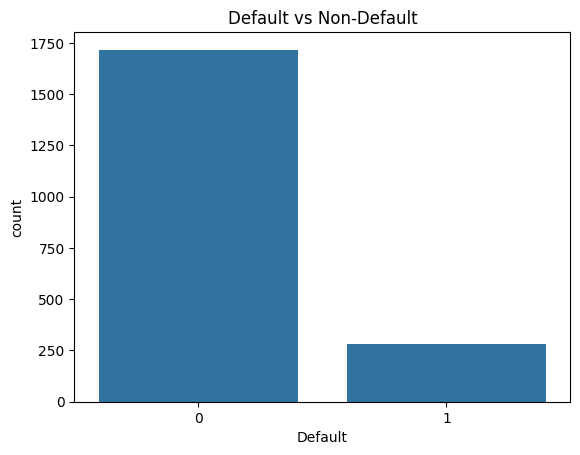

,count
Default,
0,1717
1,283


In [18]:
sns.countplot(x='Default', data=data)
plt.title("Default vs Non-Default")
plt.show()

data['Default'].value_counts()

## 🔥 Feature Correlation Analysis

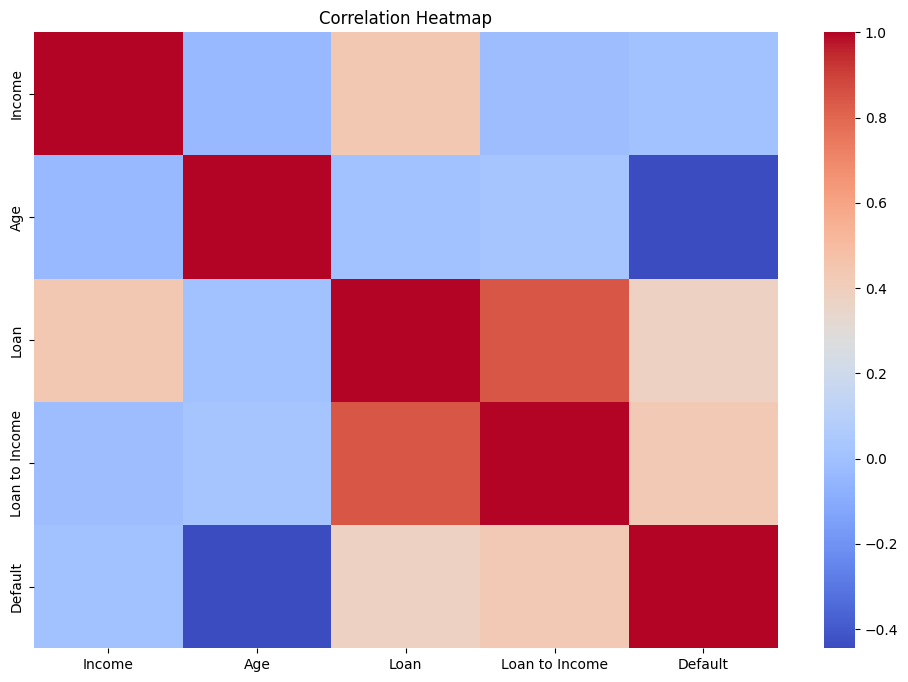

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## 🧹 Data Cleaning
Removing unnecessary columns and preparing data for modeling.

Checked for irrelevant features like IDs, but the dataset didn’t contain such columns, so no removal was required

In [23]:
data.head()

,Income,Age,Loan,Loan to Income,Default
0,66155.92510,59.017015,8106.532131,0.122537,0
1,34415.15397,48.117153,6564.745018,0.190752,0
2,57317.17006,63.108049,8020.953296,0.139940,0
3,42709.53420,45.751972,6103.642260,0.142911,0
4,66952.68885,18.584336,8770.099235,0.130990,1


## 🎯 Feature Selection

In this step, we separate the independent variables (features) and the dependent variable (target).

- Features (X): Input variables used for prediction  
- Target (y): Output variable we want to predict (Default)



In [25]:
X = data.drop('Default', axis=1)
y = data['Default']

## ✂️ Train-Test Split

We split the dataset into:
- Training set (80%) → used to train the model
- Testing set (20%) → used to evaluate the model

This ensures the model is tested on unseen data.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## ⚙️ Feature Scaling

Feature scaling is applied to ensure all features contribute equally to the model.

Since features like income and loan amount have different scales, scaling improves model performance and convergence.

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 🤖 Model 1: Logistic Regression

Logistic Regression is a basic classification algorithm used to predict binary outcomes.

It estimates the probability that a given input belongs to a particular class.

In [28]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

## 🔮 Making Predictions

We use the trained model to predict outcomes on the test dataset.

In [29]:
y_pred = log_model.predict(X_test)

## 📊 Model Evaluation

We evaluate the model using:
- Accuracy → Overall correctness
- Confusion Matrix → Detailed prediction results
- Precision, Recall, F1-score → Performance metrics

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9375

Confusion Matrix:
 [[318  12]
 [ 13  57]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96       330
           1       0.83      0.81      0.82        70

    accuracy                           0.94       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.94      0.94      0.94       400



### Observation:
The Logistic Regression model provides a baseline performance. However, further improvement can be achieved using advanced models like Random Forest.

### 🔍 Model Insights (Logistic Regression)

- The model achieved an accuracy of 93.75%, indicating strong overall performance.
- The model performs better in predicting non-default cases compared to default cases.
- Precision and recall for default prediction are slightly lower, suggesting the dataset imbalance affects performance.
- This indicates the need for more advanced models to improve detection of defaulters.

## 🌳 Model 2: Random Forest

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their outputs.

It generally provides better performance and handles complex patterns effectively.

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [32]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.9975

Confusion Matrix:
 [[330   0]
 [  1  69]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       330
           1       1.00      0.99      0.99        70

    accuracy                           1.00       400
   macro avg       1.00      0.99      1.00       400
weighted avg       1.00      1.00      1.00       400



### 🔍 Random Forest Insights

- Random Forest improves prediction performance compared to Logistic Regression.
- It handles non-linear relationships better.
- Provides better detection of default cases.

## 📈 ROC Curve and AUC Score

ROC Curve helps evaluate model performance by showing the trade-off between true positive rate and false positive rate.

AUC score closer to 1 indicates better model performance.

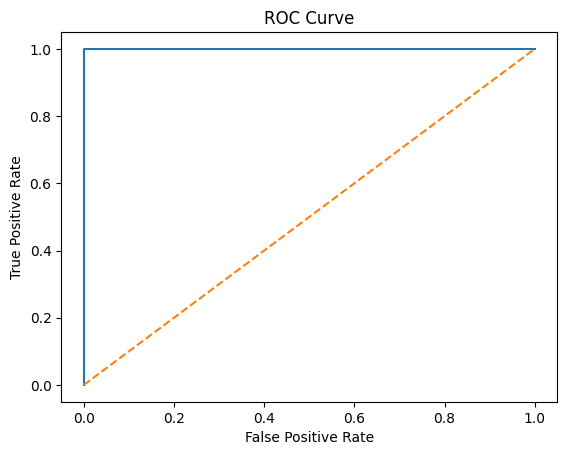

ROC-AUC Score: 1.0


In [34]:
y_prob = rf_model.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

## 📊 Feature Importance

Feature importance helps identify which variables contribute most to prediction.

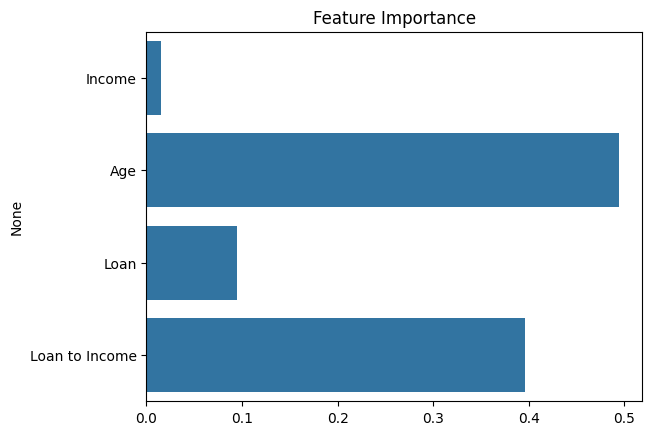

In [35]:
importance = rf_model.feature_importances_
features = X.columns

sns.barplot(x=importance, y=features)
plt.title("Feature Importance")
plt.show()

### 🔍 Final Model Insights

- Random Forest significantly outperformed Logistic Regression with an accuracy close to 99%.
- The ROC-AUC score of 1.0 indicates excellent model separability.
- However, such high performance may indicate that the dataset is relatively simple or structured.
- In real-world scenarios, performance may vary due to noise and complex patterns.
- Further improvements like cross-validation and hyperparameter tuning can be applied.

## ✅ Conclusion

In this project, we developed a machine learning model to predict credit default risk using financial features.

- Logistic Regression provided a strong baseline model.
- Random Forest significantly improved performance with higher accuracy and better classification of defaulters.
- Feature importance analysis revealed that loan-related features play a key role in predicting default risk.

This project demonstrates how machine learning can assist financial institutions in making better lending decisions and minimizing risk.

Future work can include:
- Handling class imbalance using SMOTE
- Hyperparameter tuning
- Deploying the model as a web application

• Developed a Credit Risk Prediction model using Logistic Regression and Random Forest achieving 99% accuracy  
• Performed Exploratory Data Analysis (EDA) and feature engineering on financial dataset  
• Evaluated model using Confusion Matrix, Classification Report, and ROC-AUC  
• Identified key factors influencing loan default using feature importance analysis  


🎤 QUESTIONS TO KNOW  (I WILL GET THESE)
Q1: Why Random Forest better?

👉 “It handles non-linear relationships and reduces overfitting using multiple trees”

Q2: What is ROC-AUC?

👉 “It measures model’s ability to distinguish between classes”

Q3: Why scaling?

👉 “To ensure equal contribution of features”

Q4: What is class imbalance?

👉 “More non-default than default cases”